# 03 · From forecast to money — battery optimisation & walk-forward backtest

1. Formulate the daily battery dispatch as a **MILP** (HiGHS via SciPy) with power, energy, efficiency, cycle and degradation constraints.
2. Make it **risk-aware**: Gaussian-copula price scenarios from the quantile forecast + **CVaR** (Rockafellar–Uryasev).
3. Read the **walk-forward backtest** produced by the pipeline and measure value in euros (capture ratio vs perfect foresight).

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "backend").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "backend"))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from gridalpha.data.lake import get_lake
from gridalpha.data.ingest import ingest

plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "font.size": 10})
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#898781"
lake = get_lake()
if not lake.exists("market_hourly"):
    ingest()          # auto: public APIs, falls back to the calibrated simulator
meta = lake.read_json("data_meta")
print("data mode:", meta["mode"], "| rows:", meta["rows"], "| last price:", meta["last_price_ts"])

data mode: synthetic | rows: 32807 | last price: 2026-09-26T21:00:00+00:00


In [2]:
from gridalpha.trading.battery import BatterySpec, optimise, settle
from gridalpha.trading.scenarios import quantile_scenarios
spec = BatterySpec(power_mw=10, energy_mwh=20, rte=0.88, max_cycles_per_day=1.5, degradation_eur_per_mwh=8)
if not lake.exists("bt_forecasts"):
    raise SystemExit("run the pipeline first:  python -m gridalpha.cli run --quick")
fc = lake.read("bt_forecasts")
ens_all = fc[fc.model == "ensemble"]
recent = ens_all[ens_all.delivery_date > ens_all.delivery_date.max() - pd.Timedelta(days=90)]
# pick the most uncertain recent day (widest P10–P90 band): that's where risk control matters
day = (recent.q90 - recent.q10).groupby(recent.delivery_date).mean().idxmax()
e = ens_all[ens_all.delivery_date == day].sort_values("ts")
q10, q50, q90, actual = (e[c].to_numpy() for c in ("q10", "q50", "q90", "actual"))
det = optimise(spec, q50)
orc = optimise(spec, actual)
print(f"{pd.Timestamp(day).date()}: expected {det.expected_pnl:,.0f} € | realised {settle(actual, det.charge, det.discharge, spec):,.0f} € "
      f"| perfect foresight {orc.expected_pnl:,.0f} € | solve {det.solve_ms:.1f} ms")

2026-06-30: expected 2,030 € | realised 2,371 € | perfect foresight 2,398 € | solve 22.4 ms


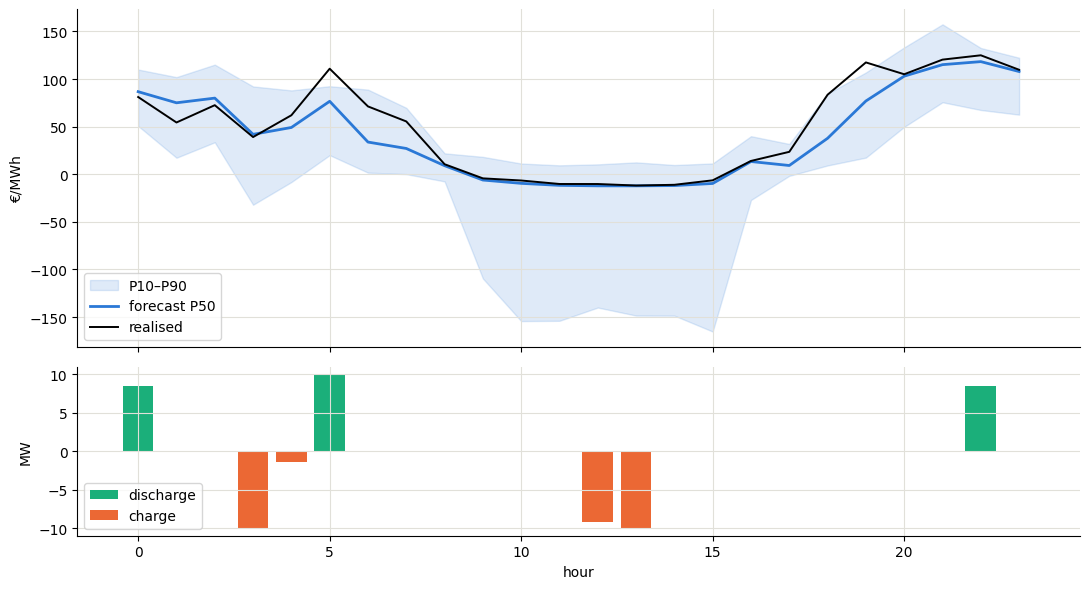

In [3]:
h = np.arange(len(q50))
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
a1.fill_between(h, q10, q90, color=BLUE, alpha=.15, label="P10–P90"); a1.plot(h, q50, color=BLUE, lw=2, label="forecast P50")
a1.plot(h, actual, color="black", lw=1.4, label="realised"); a1.set_ylabel("€/MWh"); a1.legend()
a2.bar(h, det.discharge, color=AQUA, label="discharge"); a2.bar(h, -det.charge, color=ORANGE, label="charge")
a2.set_ylabel("MW"); a2.set_xlabel("hour"); a2.legend(); plt.tight_layout(); plt.show()

## Risk: expected P&L vs CVaR
One schedule, 200 correlated price scenarios. Increasing λ trades a little expected profit for a better worst-5 % outcome.

 lambda  E[P&L]  CVaR95  cycles
    0.0  2773.5  1029.9     1.5
    0.1  2773.5  1029.9     1.5
    0.2  2773.5  1029.9     1.5
    0.3  2760.1  1060.4     1.5
    0.5  2678.4  1158.5     1.3
    0.7  2614.4  1208.6     1.1
    0.9  2609.9  1210.0     1.1


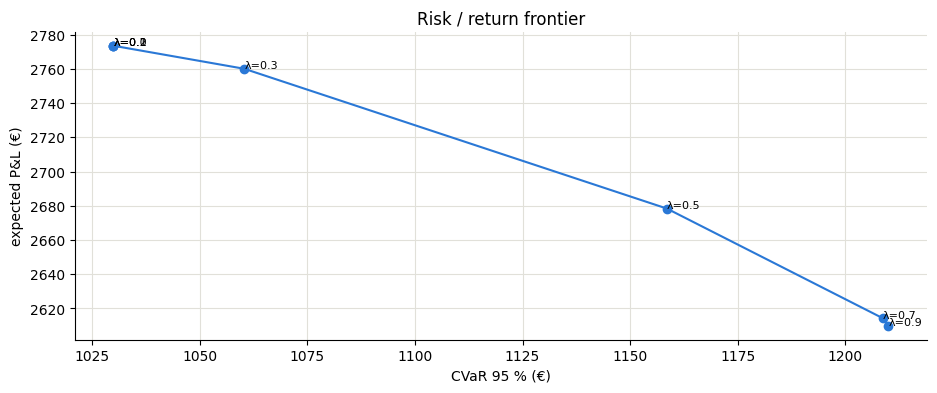

In [4]:
sc = quantile_scenarios(q10, q50, q90, n=200, rho=0.85, seed=1)
pts = []
for lam in (0, .1, .2, .3, .5, .7, .9):
    r = optimise(spec, q50, sc, risk_aversion=lam)
    pts.append({"lambda": lam, "E[P&L]": r.scenario_pnl.mean(), "CVaR95": r.risk()["cvar"], "cycles": r.discharge.sum() / spec.energy_mwh})
front = pd.DataFrame(pts); print(front.round(1).to_string(index=False))
plt.plot(front["CVaR95"], front["E[P&L]"], "-o", color=BLUE)
for _, r in front.iterrows(): plt.annotate(f"λ={r['lambda']}", (r["CVaR95"], r["E[P&L]"]), fontsize=8)
plt.xlabel("CVaR 95 % (€)"); plt.ylabel("expected P&L (€)"); plt.title("Risk / return frontier"); plt.show()

## Walk-forward backtest (written by the pipeline)

In [5]:
summ = lake.read_json("bt_summary")
tm = pd.DataFrame(summ["trading_metrics"]).T.sort_values("total_pnl_eur", ascending=False)
print(summ["period"]); tm[["total_pnl_eur", "eur_per_mw_year", "capture_ratio", "worst_day_eur", "loss_day_share", "avg_cycles_per_day"]]

{'start': '2025-09-27', 'end': '2026-09-26', 'days': 365}


,total_pnl_eur,eur_per_mw_year,capture_ratio,worst_day_eur,loss_day_share,avg_cycles_per_day
oracle,632957.0,63296.0,1.0000,27.0,0.0000,1.333
lgbm,574217.0,57422.0,0.9072,-285.0,0.0110,1.315
ensemble,572215.0,57222.0,0.9040,-596.0,0.0110,1.317
ensemble_cvar,567794.0,56779.0,0.8970,-307.0,0.0082,1.285
tide,549856.0,54986.0,0.8687,-596.0,0.0137,1.335
profile7,436217.0,43622.0,0.6892,-1071.0,0.0685,1.335
naive_d1,342355.0,34236.0,0.5409,-1704.0,0.1589,1.333


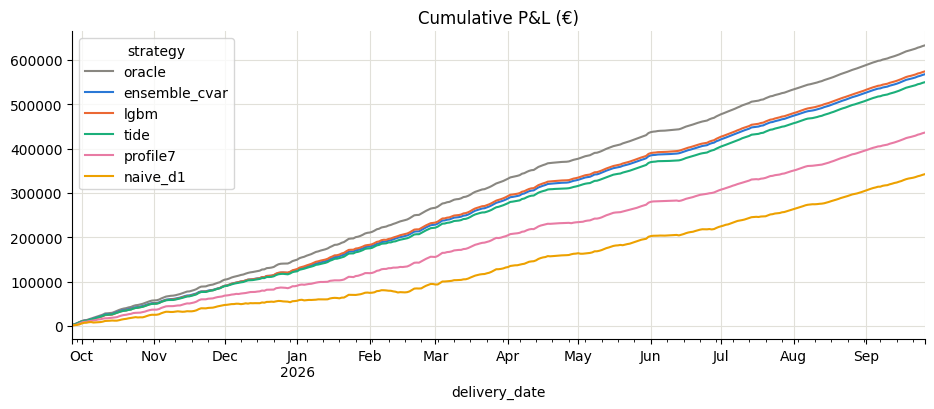

In [6]:
daily = lake.read("bt_daily").pivot_table(index="delivery_date", columns="strategy", values="pnl")
cols = {"oracle": GRAY, "ensemble_cvar": BLUE, "lgbm": ORANGE, "tide": AQUA, "profile7": MAGENTA, "naive_d1": YELLOW}
daily[[c for c in cols if c in daily]].cumsum().plot(color=[cols[c] for c in cols if c in daily], title="Cumulative P&L (€)")
plt.show()

## Does accuracy or ranking drive money?
Per day, correlate the capture ratio of the ensemble strategy with its MAE and with its Kendall τ.

Spearman(capture, tau) = 0.592 | Spearman(capture, MAE) = -0.216


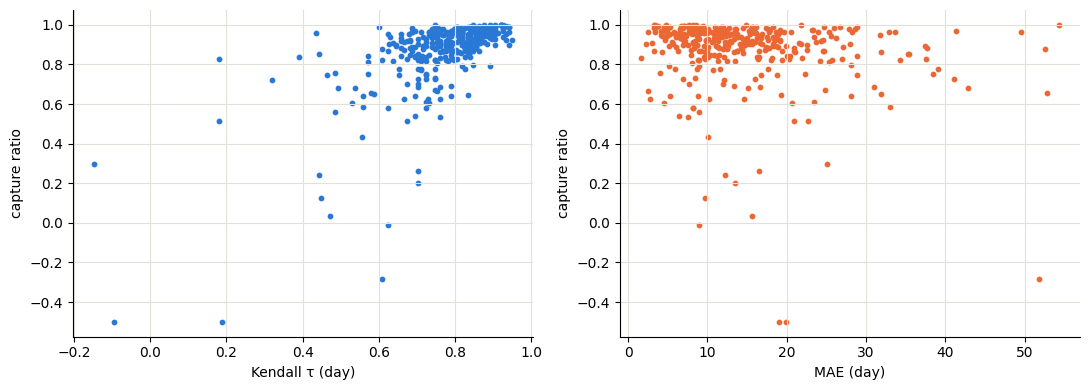

In [7]:
from scipy.stats import kendalltau, spearmanr
e = fc[fc.model == "ensemble"]
per_day = e.groupby("delivery_date").apply(lambda g: pd.Series({
    "mae": (g.actual - g.q50).abs().mean(), "tau": kendalltau(g.actual, g.q50).statistic}))
cap = (daily["ensemble"] / daily["oracle"]).rename("capture")
j = per_day.join(cap).dropna()
print("Spearman(capture, tau) =", round(spearmanr(j.capture, j.tau).statistic, 3),
      "| Spearman(capture, MAE) =", round(spearmanr(j.capture, j.mae).statistic, 3))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(j.tau, j.capture.clip(-.5, 1.05), s=10, color=BLUE); ax[0].set(xlabel="Kendall τ (day)", ylabel="capture ratio")
ax[1].scatter(j.mae, j.capture.clip(-.5, 1.05), s=10, color=ORANGE); ax[1].set(xlabel="MAE (day)", ylabel="capture ratio")
plt.tight_layout(); plt.show()

**Takeaways**
* The decision layer turns forecast quality into euros; the capture ratio is the KPI a trading desk actually cares about.
* Ranking quality (τ) is tightly linked to captured value — consistent with recent literature (arXiv:2604.12082).
* Risk aversion costs little expected profit and reduces cycling (battery wear) — a knob the trader controls in the UI.